In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

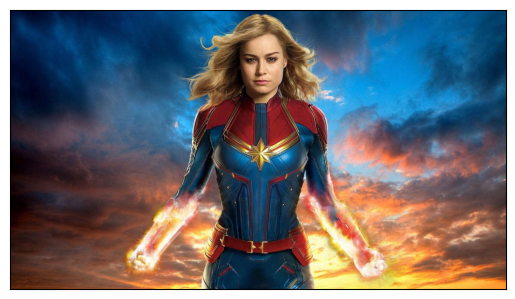

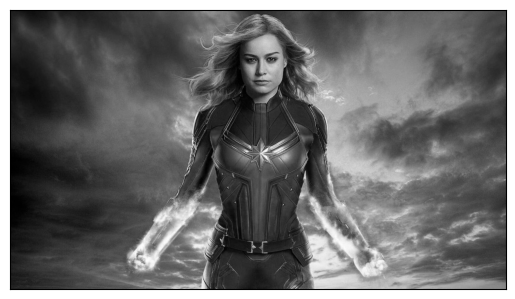

In [10]:

#read the image
img=mpimg.imread('Captain-Marvel.jpeg')
imgplot = plt.imshow(img)
plt.show(plt.xticks([]), plt.yticks([]))

# Convert color image to grayscale for Viola-Jones
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
imgplot = plt.imshow(gray_img, cmap = 'gray')
plt.show(plt.xticks([]), plt.yticks([]))

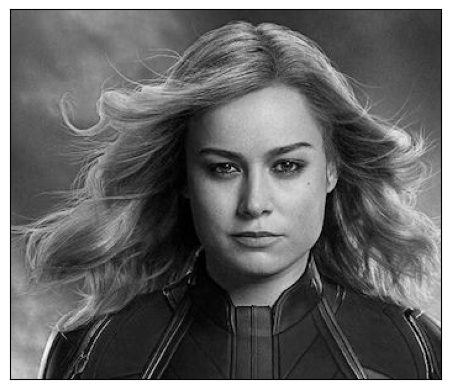

In [11]:
# Crop a region of interest
roi = img[0:300, 450:800]
gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
imgplot = plt.imshow(gray_roi, cmap = 'gray')
plt.show(plt.xticks([]), plt.yticks([]))

In [12]:
# Haar Cascade classifier files basically come along with OpenCV.
# Load the classifier and create a cascade object for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

The face_cascade object has a method `detectMultiScale()`, which receives an image as an argument and runs the classifier cascade over the image. The term `MultiScale` indicates that the algorithm looks at subregions of the image in multiple scales, to detect faces of varying sizes. Next, we’re going to create a function detecting a face and drawing a rectangle around it.
To detect the face, we can use the method `detectMulitiScale()` of the classifier `face_cascade` that we loaded above. It returns the four points of the identified region so we’ll draw a rectangle at that position. `scaleFactor` is a parameter for how much the image size is reduced at each image scale and `minNeighbors` for how many neighbors each candidate rectangle should be trained. Now let’s apply this function to the image and see the result.

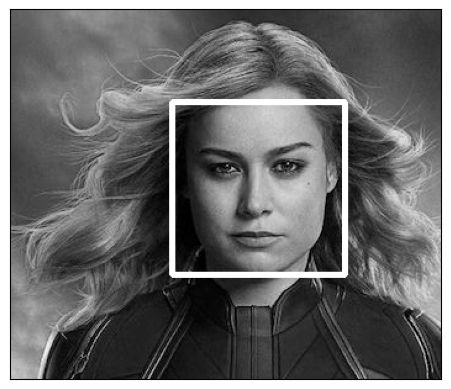

In [13]:
#find face on the roi
faces = face_cascade.detectMultiScale(gray_roi, scaleFactor=1.3, minNeighbors=5)

# Copy the image
gray_copy = gray_roi.copy()
# Draw the face bounding box
for (x, y, w, h) in faces:
        cv2.rectangle(gray_copy, (x, y), (x+w, y+h), (255, 255, 255), 3)

imgplot = plt.imshow(gray_copy, cmap = 'gray')
plt.show(plt.xticks([]), plt.yticks([]))

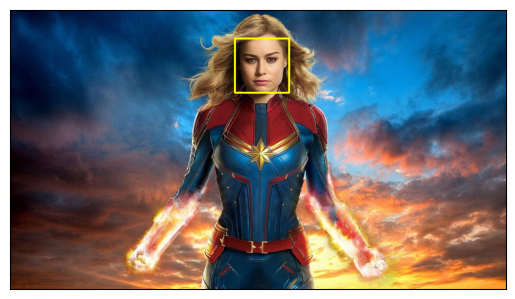

In [14]:
#find face on the whole image
faces1 = face_cascade.detectMultiScale(gray_img, scaleFactor = 1.1, minNeighbors = 5)
# Copy the image
img_copy = img.copy()
# Draw the face bounding box in the original color image
for (x, y, w, h) in faces1:
        cv2.rectangle(img_copy, (x, y), (x+w, y+h), (255, 255, 0), 3)

imgplot = plt.imshow(img_copy)
plt.show(plt.xticks([]), plt.yticks([]))

We can implement this classifier to an image with multiple faces as well.

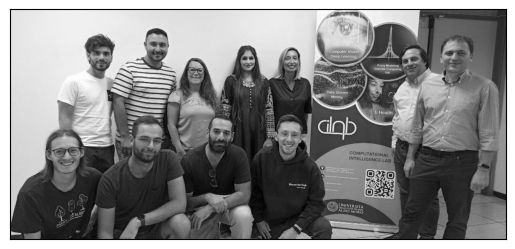

In [16]:
# Load the image file and convert the color mode
multiface=mpimg.imread('gruppo-cilab.jpeg')

multiface_gray = cv2.cvtColor(multiface, cv2.COLOR_BGR2GRAY)
imgplot = plt.imshow(multiface_gray, cmap='gray')
plt.show(plt.xticks([]), plt.yticks([]))


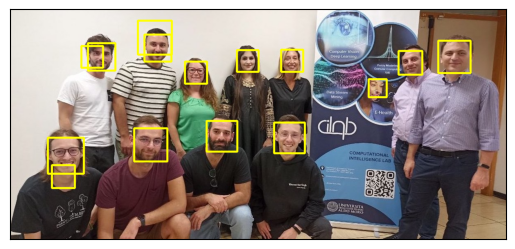

In [17]:
#find face on the whole image
faces1 = face_cascade.detectMultiScale(multiface_gray, scaleFactor = 1.1,minNeighbors = 5)
multi_copy = multiface.copy()
# Draw the face bounding box in the original color image
for (x, y, w, h) in faces1:
        cv2.rectangle(multi_copy, (x, y), (x+w, y+h), (255, 255, 0), 3)

imgplot = plt.imshow(multi_copy)
plt.show(plt.xticks([]), plt.yticks([]))